## MODELING (KNN IMPUTATION VERSION)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

#adding the parent directory to the system path to import the custom module
sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils.ml_stratifiers import MultilabelStratifiedShuffleSplit

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from scipy.stats import randint, loguniform
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [3]:
file_path = r'C:\unibo-dtm-ml-2526-cervical-cancer-predictor\data\data_after_imputation\knn_imputed.csv'
df = pd.read_csv(file_path)

# repeat the data profiling pipeline for the newly cleaned data
df = pd.read_csv(file_path)

print("\nDataset Info: \n")
print(df.info())

#check whether everything went smoothly at the data cleaning stage
print("\nMissing Values: \n")
print(df.isnull().sum()) 


print("\nDescriptive Statistics:")
print(df.describe(include='all'))



Dataset Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              835 non-null    float64
 1   Number of sexual partners        835 non-null    float64
 2   First sexual intercourse         835 non-null    float64
 3   Num of pregnancies               835 non-null    float64
 4   Smokes (years)                   835 non-null    float64
 5   Smokes (packs/year)              835 non-null    float64
 6   Hormonal Contraceptives (years)  835 non-null    float64
 7   IUD (years)                      835 non-null    float64
 8   STDs (number)                    835 non-null    float64
 9   STDs: Viral group                835 non-null    float64
 10  STDs: Bacterial group            835 non-null    float64
 11  STDs:condylomatosis              835 non-null    float64
 12  STDs:

In [4]:
targets = ['Biopsy', 'Hinselmann', 'Schiller', 'Citology']
y = df[targets]
X = df.drop(columns=targets)

"""use msss (MultilabelStratifiedShuffleSplit) to split the data into train and test sets, 
ensuring that the distribution of the target variables is preserved in both sets.
This is particularly important in multilabel classification problems, where each instance can belong to multiple classes simultaneously.
Furthermore, this form of data splitting is needed for such an imbalanced dataset, where some classes may be underrepresented. 
"""

msss = MultilabelStratifiedShuffleSplit(n_splits=5, test_size=0.2,random_state=0)
msss.get_n_splits(X, y)

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"Training samples: {X_train.shape[0]} ({len(y_train[y_train.sum(axis=1) > 0])} with at least one positive target)")
print(f"Testing samples:  {X_test.shape[0]} ({len(y_test[y_test.sum(axis=1) > 0])} with at least one positive target)")

X_train: (668, 19)
X_test: (167, 19)
y_train: (668, 4)
y_test: (167, 4)
Training samples: 668 (80 with at least one positive target)
Testing samples:  167 (21 with at least one positive target)


### LOGISTIC REGRESSION

In [5]:
ovr_clf = MultiOutputClassifier(LogisticRegression(class_weight='balanced', random_state=42),n_jobs=-1)

all_reports = []

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    ovr_clf.fit(X_train, y_train)
    y_pred = ovr_clf.predict(X_test)
    
    report_dict = classification_report(y_test, y_pred, target_names=targets, zero_division=0, output_dict=True)
    all_reports.append(report_dict)
    
#calculate the average precision, recall, and f1-score for each target across all folds
logR_final_results = {}
for target in targets + ['macro avg']:
    logR_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_reports])
    }

#display the final results in a DataFrame for better readability

print("=== LOGISTIC REGRESSION FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(logR_final_results).T.round(3))

=== LOGISTIC REGRESSION FINAL AVERAGE PERFORMANCE (5-FOLDS) ===
            precision  recall  f1-score
Biopsy          0.162   0.600     0.255
Hinselmann      0.044   0.314     0.077
Schiller        0.184   0.533     0.274
Citology        0.070   0.333     0.115
macro avg       0.115   0.445     0.180


### XGBOOST

In [6]:
#set up a continuous parameter grid to explore a wider range of hyperparameters
random_grid = {
    'estimator__scale_pos_weight': randint(1, 6), 
    'estimator__max_depth': randint(2, 6),        
    'estimator__learning_rate': loguniform(0.01, 0.1), 
    'estimator__n_estimators': randint(100, 600),
    'estimator__reg_lambda': loguniform(1, 100)   
}

xgb_estimator = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42
)

multilabel_model = MultiOutputClassifier(xgb_estimator, n_jobs=-1)

xgb_random = RandomizedSearchCV(
    estimator=multilabel_model,
    param_distributions=random_grid, 
    n_iter=30, #30 iterations for a more thorough search
    cv=3, #3-fold cross-validation for better generalization
    verbose=1, #verbose output to track progress
    random_state=42,
    scoring='average_precision', #optimize for average precision to better handle class imbalance
    n_jobs=-1
)

#list storing results for each of the five folds, to be averaged at the end for a more robust performance estimate
all_reports = []

#dynamic cross-validation loop with dynamic thresholding to optimize for recall >= 0.60 for each target
for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    xgb_random.fit(X_train, y_train)
    y_probs_list = xgb_random.predict_proba(X_test)

    prob_matrix = np.transpose([prob[:, 1] for prob in y_probs_list])
    y_pred = np.zeros_like(prob_matrix)
    
    # Dynamically find the best threshold for EACH target to hit your 0.6 Recall goal
    for i in range(len(targets)):
        target_true = y_test.iloc[:, i]
        target_probs = prob_matrix[:, i]
        
        precisions, recalls, thresholds = precision_recall_curve(target_true, target_probs)
        
        # Lock Recall at >= 0.60
        valid_indices = np.where(recalls >= 0.60)[0]
        
        if len(valid_indices) > 0:
            best_index = valid_indices[np.argmax(precisions[valid_indices])]
            best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5
        else:
            best_threshold = 0.15 # Softer clinical fallback
            
        y_pred[:, i] = (target_probs >= best_threshold).astype(int)
    
    report_dict = classification_report(y_test, y_pred, target_names=targets, zero_division=0, output_dict=True)
    all_reports.append(report_dict)

print("Best Parameters:", xgb_random.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'estimator__learning_rate': np.float64(0.03488960745139221), 'estimator__max_depth': 2, 'estimator__n_estimators': 256, 'estimator__reg_lambda': np.float64(40.215545266902886), 'estimator__scale_pos_weight': 1}


In [7]:
xgb_final_results = {}
for target in targets + ['macro avg']:
    xgb_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_reports])
    }
    
print("=== XGBOOST FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(xgb_final_results).T.round(3))

=== XGBOOST FINAL AVERAGE PERFORMANCE (5-FOLDS) ===
            precision  recall  f1-score
Biopsy          0.190   0.673     0.285
Hinselmann      0.051   0.886     0.096
Schiller        0.183   0.693     0.266
Citology        0.082   0.711     0.146
macro avg       0.126   0.741     0.198


<Figure size 1000x800 with 0 Axes>

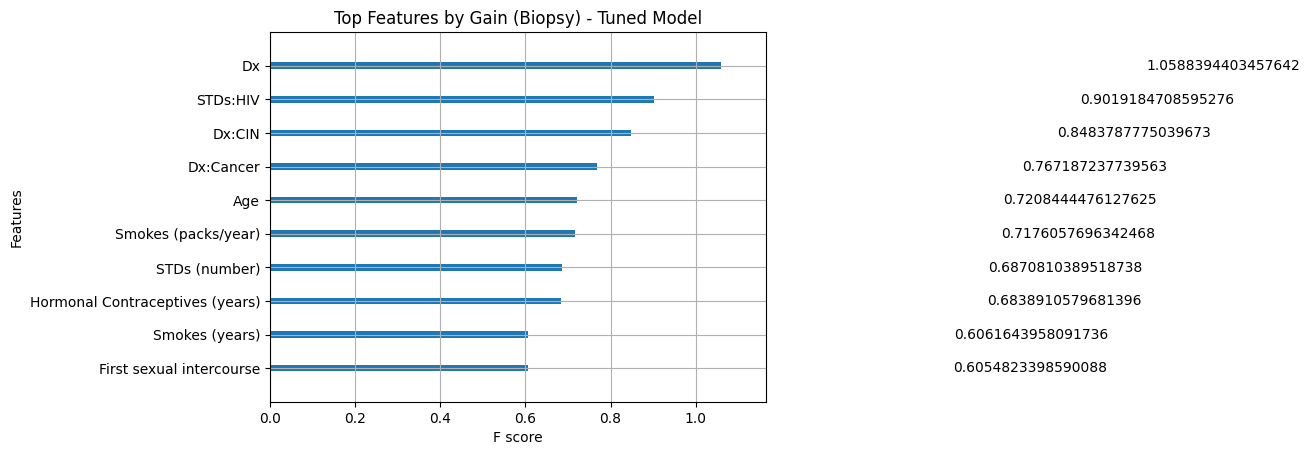

In [8]:
#feature importance for the biopsy target in the best fitted model
best_fitted_multilabel = xgb_random.best_estimator_
biopsy_estimator = best_fitted_multilabel.estimators_[0]

plt.figure(figsize=(10, 8))
xgb.plot_importance(biopsy_estimator, importance_type='gain', max_num_features=10)
plt.title("Top Features by Gain (Biopsy) - Tuned Model")
plt.show()

### RANDOM FOREST

In [9]:
random_grid_rf = {
    'n_estimators': [100, 200, 500, 800],
    'max_depth': [3, 5, 8, 10, None], 
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],    
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'bootstrap': [True, False],        
    'class_weight': ['balanced', 'balanced_subsample']
}

forest_cls = RandomForestClassifier(criterion="entropy",
                                    n_estimators=500,
                                    class_weight='balanced_subsample', 
                                    random_state=42) # initialize the model

rf_param_dist = {f'estimator__{k}': v for k, v in random_grid_rf.items()}

rf_random = RandomizedSearchCV(
    estimator=MultiOutputClassifier(forest_cls, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10, 
    cv=3, 
    scoring='average_precision', 
    verbose=1, 
    n_jobs=-1,
    random_state=42
)

all_reports = []

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf_random.fit(X_train, y_train) 

    y_probs_list = rf_random.predict_proba(X_test)

    prob_matrix = np.transpose([prob[:, 1] for prob in y_probs_list])
    y_pred = np.zeros_like(prob_matrix)
    
    for i in range(len(targets)):
        target_true = y_test.iloc[:, i]
        target_probs = prob_matrix[:, i]
        
        precisions, recalls, thresholds = precision_recall_curve(target_true, target_probs)
        
        # Lock Recall at >= 0.60
        valid_indices = np.where(recalls >= 0.60)[0]
        
        if len(valid_indices) > 0:
            best_index = valid_indices[np.argmax(precisions[valid_indices])]
            best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5
        else:
            best_threshold = 0.15 # Softer clinical fallback
            
        y_pred[:, i] = (target_probs >= best_threshold).astype(int)
    
report_dict = classification_report(y_test, y_pred, target_names=targets, zero_division=0, output_dict=True)
all_reports.append(report_dict)

print("Best parameters:", rf_random.best_params_)    

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'estimator__n_estimators': 100, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 4, 'estimator__max_features': 'log2', 'estimator__max_depth': 5, 'estimator__criterion': 'log_loss', 'estimator__class_weight': 'balanced', 'estimator__bootstrap': True}


In [10]:
rforest_final_results = {}
for target in targets + ['macro avg']:
    rforest_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_reports])
    }
    
print("=== RANDOM FOREST FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(rforest_final_results).T.round(3))

=== RANDOM FOREST FINAL AVERAGE PERFORMANCE (5-FOLDS) ===
            precision  recall  f1-score
Biopsy          0.149   0.636     0.241
Hinselmann      0.046   0.714     0.087
Schiller        0.129   0.600     0.212
Citology        0.064   1.000     0.121
macro avg       0.097   0.738     0.165


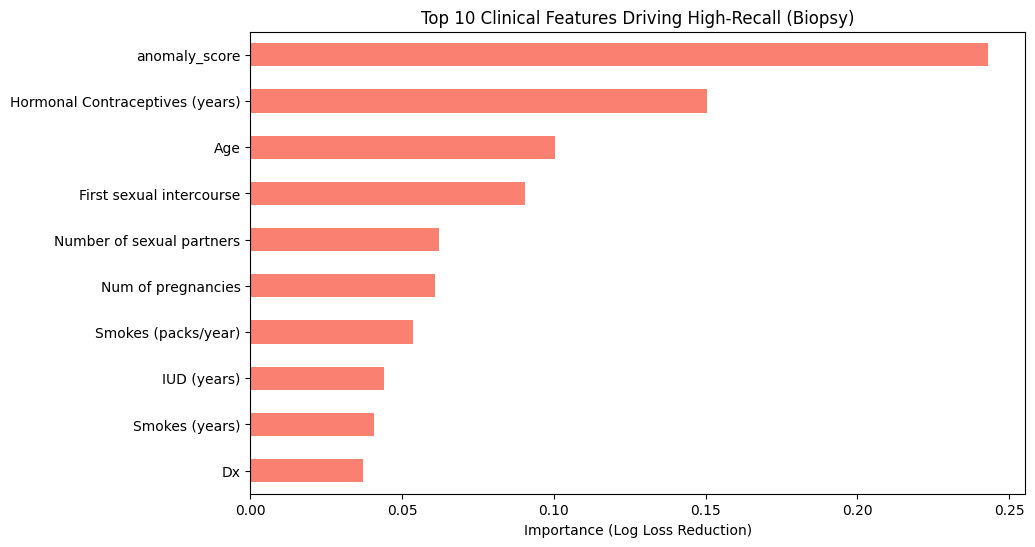

In [11]:
biopsy_forest = rf_random.best_estimator_.estimators_[0] 

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(biopsy_forest.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title("Top 10 Clinical Features Driving High-Recall (Biopsy)")
plt.xlabel("Importance (Log Loss Reduction)")
plt.gca().invert_yaxis()
plt.show()

### SVM

In [12]:
param_grid = {
    'estimator__estimator__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'estimator__estimator__degree': [2, 3, 4], # Only for 'poly' kernel
    'estimator__estimator__C': [0.01, 0.1, 1, 10], # 
    'estimator__estimator__gamma': ['scale', 'auto'], 
}

svc = SVC(probability=True, class_weight='balanced')

#wrapping the SVR model in MultiOutputRegressor
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('estimator', MultiOutputClassifier(svc))
])

all_svc_reports = []

random_svc = RandomizedSearchCV(estimator=pipeline, 
                           param_distributions=param_grid,
                           n_iter=30, 
                           cv=3, 
                           verbose=2, 
                           n_jobs=-1, 
                           scoring='average_precision',
                           random_state=42
                           )

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    random_svc.fit(X_train, y_train)

    y_probs_list = random_svc.predict_proba(X_test)

    prob_matrix = np.transpose([prob[:, 1] for prob in y_probs_list])
    y_pred_svc = np.zeros_like(prob_matrix)
    
    for i in range(len(targets)):
        target_true = y_test.iloc[:, i]
        target_probs = prob_matrix[:, i]
        
        precisions, recalls, thresholds = precision_recall_curve(target_true, target_probs)
        
        # Lock Recall at >= 0.60
        valid_indices = np.where(recalls >= 0.60)[0]
        
        if len(valid_indices) > 0:
            best_index = valid_indices[np.argmax(precisions[valid_indices])]
            best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5
        else:
            best_threshold = 0.15 # Softer clinical fallback
            
        y_pred_svc[:, i] = (target_probs >= best_threshold).astype(int)
    report_dict = classification_report(y_test, y_pred_svc, target_names=targets, zero_division=0, output_dict=True)
    all_svc_reports.append(report_dict)

print("Best Parameters:", random_svc.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'estimator__estimator__kernel': 'poly', 'estimator__estimator__gamma': 'auto', 'estimator__estimator__degree': 2, 'estimator__estimator__C': 10}


In [14]:
svc_final_results = {}
for target in targets + ['macro avg']:
    svc_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_svc_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_svc_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_svc_reports])
    }
    
print("=== SVC FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(svc_final_results).T.round(3))

=== SVC FINAL AVERAGE PERFORMANCE (5-FOLDS) ===
            precision  recall  f1-score
Biopsy          0.216   0.709     0.311
Hinselmann      0.054   0.914     0.102
Schiller        0.201   0.627     0.299
Citology        0.083   0.844     0.149
macro avg       0.139   0.774     0.215


### MULTILABEL KNN


In [15]:
param_grid = {
    'estimator__estimator__n_neighbors': [9, 11, 29],
    'estimator__estimator__weights': ['uniform', 'distance'],
    'estimator__estimator__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'estimator__estimator__leaf_size': [10, 20, 30],
    'estimator__estimator__p': [1, 2]
    }



pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('estimator', MultiOutputClassifier(KNeighborsClassifier()))
])

random_knn = RandomizedSearchCV(estimator=pipeline,
                                param_distributions=param_grid,
                                cv=5,
                                scoring='average_precision',
                                n_jobs=-1,
                                random_state=42
                                )

all_knn_reports = []

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    random_knn.fit(X_train, y_train)

    y_probs_list = random_knn.predict_proba(X_test)

    prob_matrix = np.transpose([prob[:, 1] for prob in y_probs_list])
    y_pred_knn = np.zeros_like(prob_matrix)
    
    for i in range(len(targets)):
        target_true = y_test.iloc[:, i]
        target_probs = prob_matrix[:, i]
        
        precisions, recalls, thresholds = precision_recall_curve(target_true, target_probs)
        
        # Lock Recall at >= 0.60
        valid_indices = np.where(recalls >= 0.60)[0]
        
        if len(valid_indices) > 0:
            best_index = valid_indices[np.argmax(precisions[valid_indices])]
            best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5
        else:
            best_threshold = 0.15 # Softer clinical fallback
            
        y_pred_knn[:, i] = (target_probs >= best_threshold).astype(int)

    report_dict = classification_report(y_test, y_pred_knn, target_names=targets, zero_division=0, output_dict=True)
    all_knn_reports.append(report_dict)
    
print("Best Parameters:", random_knn.best_params_)

Best Parameters: {'estimator__estimator__weights': 'distance', 'estimator__estimator__p': 1, 'estimator__estimator__n_neighbors': 29, 'estimator__estimator__leaf_size': 10, 'estimator__estimator__algorithm': 'brute'}


In [16]:
knn_final_results = {}
for target in targets + ['macro avg']:
    knn_final_results[target] = {
        'precision': np.mean([r[target]['precision'] for r in all_knn_reports]),
        'recall': np.mean([r[target]['recall'] for r in all_knn_reports]),
        'f1-score': np.mean([r[target]['f1-score'] for r in all_knn_reports])
    }
    
print("=== KNN FINAL AVERAGE PERFORMANCE (5-FOLDS) ===")
print(pd.DataFrame(knn_final_results).T.round(3))

=== KNN FINAL AVERAGE PERFORMANCE (5-FOLDS) ===
            precision  recall  f1-score
Biopsy          0.233   0.745     0.303
Hinselmann      0.064   0.886     0.115
Schiller        0.223   0.653     0.311
Citology        0.078   0.844     0.141
macro avg       0.149   0.782     0.218
